<a href="https://colab.research.google.com/github/Rishsing73/rishsing73.github.io/blob/master/CT_image%20Segmentation_test_Save.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install segmentation-models
!pip install  tensorflow==2.1.0
!pip install keras==2.3.1
import tensorflow as tf
import segmentation_models as sm
import glob
import cv2
import os
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
import albumentations as A



     |████████████████████████████████| 51kB 7.2MB/s 
     |████████████████████████████████| 421.8MB 18kB/s 
     |████████████████████████████████| 3.9MB 28.1MB/s 
     |████████████████████████████████| 450kB 53.0MB/s 
  Created wheel for gast: filename=gast-0.2.2-cp36-none-any.whl size=7540 sha256=8482bb1f18f231eb99a3a28059b76c81bd345a409a0959da46e875096d475405
  Stored in directory: /root/.cache/pip/wheels/5c/2e/7e/a1d4d4fcebe6c381f378ce7743a3ced3699feb89bcfbdadadd
Successfully built gast
ERROR: tensorflow-probability 0.12.1 has requirement gast>=0.3.2, but you'll have gast 0.2.2 which is incompatible.
  Found existing installation: tensorboard 2.4.1
    Uninstalling tensorboard-2.4.1:
      Successfully uninstalled tensorboard-2.4.1
  Found existing installation: gast 0.3.3
    Uninstalling gast-0.3.3:
      Successfully uninstalled gast-0.3.3
  Found existing installation: tensorflow-estimator 2.4.0
    Uninstalling tensorflow-estimator-2.4.0:
      Successfully uninstalled tens

Using TensorFlow backend.


Segmentation Models: using `keras` framework.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from keras.models import load_model
from keras.utils.generic_utils import get_custom_objects

model_save_name = 'classifier_keras_1'
path = F"/content/drive/My Drive/test/{model_save_name}" 


get_custom_objects().update({'dice_loss': sm.losses.DiceLoss()})
get_custom_objects().update({'iou_score': sm.metrics.IOUScore(threshold=0.5)})
model2 = load_model(path)

In [ ]:
l = os.listdir('/content/drive/My Drive/P08/M07_P08/')
dir_files = l
d = np.sort(dir_files)
train_images = []
i = 0
for directory_path in glob.glob("/content/drive/My Drive/P08/M07_P08/"):
  for i in range(len(d)):
    for img_path in glob.glob(os.path.join(directory_path, d[i])):
      img = cv2.imread(img_path)
      color_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      train_images.append(color_img)   
train_images = np.array(train_images)


np.shape(train_images)
print(d)

['M07_03.png' 'M07_04.png' 'M07_05.png' 'M07_06.png' 'M07_07.png'
 'M07_08.png' 'M07_09.png' 'M07_10.png' 'M07_11.png' 'M07_12.png'
 'M07_13.png' 'M07_14.png' 'M07_15.png' 'M07_16.png' 'M07_17.png'
 'M07_18.png' 'M07_19.png' 'M07_20.png' 'M07_21.png' 'M07_22.png'
 'M07_23.png' 'M07_24.png' 'M07_25.png' 'M07_26.png' 'M07_27.png'
 'M07_28.png' 'M07_29.png' 'M07_30.png' 'M07_31.png' 'M07_32.png'
 'M07_33.png' 'M07_34.png' 'M07_35.png' 'M07_36.png' 'M07_37.png'
 'M07_38.png' 'M07_39.png' 'M07_40.png' 'M07_41.png' 'M07_42.png'
 'M07_43.png' 'M07_44.png' 'M07_45.png' 'M07_46.png' 'M07_47.png'
 'M07_48.png' 'M07_49.png' 'M07_50.png' 'M07_51.png' 'M07_52.png'
 'M07_53.png' 'M07_54.png' 'M07_55.png' 'M07_56.png' 'M07_57.png'
 'M07_58.png' 'M07_59.png' 'M07_60.png' 'M07_61.png' 'M07_62.png'
 'M07_63.png' 'M07_64.png' 'M07_65.png' 'M07_66.png' 'M07_67.png'
 'M07_68.png' 'M07_69.png' 'M07_70.png' 'M07_71.png' 'M07_72.png'
 'M07_73.png' 'M07_74.png' 'M07_75.png' 'M07_76.png' 'M07_77.png'
 'M07_78.p

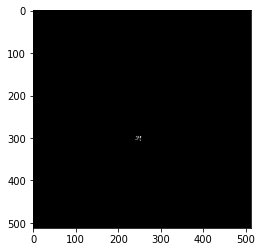

In [ ]:
for j in range(len(train_images)):
  # test_img = cv2.imread('/content/drive/My Drive/test/train130.png', cv2.IMREAD_COLOR)       
  # #test_img = cv2.resize(test_img, (SIZE_Y, SIZE_X))
  # test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
  
  test_img = train_images[j,:,:,:]
  test_img = np.expand_dims(test_img, axis=0)
  prediction = model2.predict(test_img)
  prediction_image = prediction.reshape(512,512)
  plt.imshow(prediction_image, cmap='gray')
  plt.imsave('/content/drive/My Drive/P08/M07/mask'+str(j)+'.jpg', prediction_image, cmap='gray')